# 07 — Arc Analysis

Detect and quantify the rise-and-fall of abstract language across literary history.

Uses two regression approaches:
- **Quadratic**: `score ~ year + year²` — tests for inverted-U, estimates peak year
- **Piecewise linear**: two slopes with optimal breakpoint — measures abstracting/concretizing rates

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')
from abstraction.analysis import *
from abstraction.plotting import plot_arc, plot_arc_by_genre

## Load all scored corpora

Single load used throughout the notebook.

In [3]:
combined = load_all_scored()
print(f'{len(combined)} texts, {combined.year.min():.0f}-{combined.year.max():.0f}, {combined.corpus_name.nunique()} corpora')
combined.genre_harmonized.value_counts()

Loading hathi_englit:  57%|█████▊    | 23/40 [00:24<00:17,  1.02s/it]  

  Skipping hathi: No metadata found at /Users/rj416/lltk_data/corpora/hathi


Loading txtlab: 100%|██████████| 40/40 [00:28<00:00,  1.41it/s]           


1070320 texts, -800-9179, 32 corpora


genre_harmonized
Periodical             259680
Poetry                 252752
Fiction                247297
Primary Document       178364
                        37567
Drama                   28861
Criticism               24994
Essay/Treatise          11096
Nonfiction              10427
Sermon                   6007
Letters                  5221
Biography                3894
Film                      967
Fictional Narration       868
Fictional Dialogue        868
Legal                     636
Political                 227
Dialogue                  176
Oratory                   173
novel                     106
Miscellany                 41
Other                      37
stories                    14
Juvenilia                  10
theatre                     8
autobio                     7
folktales                   7
poetry_mod                  4
essay                       4
poetry_trad                 3
history                     1
travel                      1
market_lit             

In [4]:
genres = {'Periodical', 'Poetry', 'Fiction'}
combined2 = combined[combined.genre_harmonized.isin(genres)].drop_duplicates(subset=['corpus_name', 'id'])

In [5]:
combined2.year.min()

np.float64(-800.0)

In [6]:
# combined2.groupby(['genre_harmonized', 'corpus_name']).size().reset_index(name='n_texts').sort_values(['genre_harmonized', 'n_texts'], ascending=[True, False]).set_index(['genre_harmonized', 'corpus_name'])

In [7]:
import textwrap
def arc_caption(combined_df, genres=None, wrap_by=160):
    """Generate a caption string summarizing texts per genre and corpus.

    Parameters
    ----------
    combined_df : DataFrame
        Combined scored DataFrame with genre_harmonized and corpus_name columns.
    genres : list, optional
        Genres to include. If None, uses all genres present.

    Returns
    -------
    str
        Caption like "Fiction (45,231 texts: hathi_englit 30,102, chadwyck 5,012, ...); ..."
    """
    df = combined_df
    if genres is not None:
        df = df[df["genre_harmonized"].isin(genres)]

    parts = []
    for genre in sorted(df["genre_harmonized"].dropna().unique()):
        gdf = df[df["genre_harmonized"] == genre]
        corpus_counts = gdf["corpus_name"].value_counts()
        corpus_str = " + ".join(
            f"{name.replace('_', ' ').title()} ({count:,})" for name, count in corpus_counts.items()
        )
        opart = f"- {genre}: {len(gdf):,} texts = {corpus_str}"
        parts.append(opart)
    
    # Format output using textwrap to wrap lines at 80 characters
    def _wrap(part):
        return textwrap.fill(part, width=wrap_by, break_long_words=False, break_on_hyphens=False)
    
    out = "\n\n".join(_wrap(part).replace("\n", "\n        ") for part in parts)
    return out

In [8]:
combined2.query('genre_harmonized == "Periodical" & corpus_name == "coha"')[['title', 'author', 'year']].sort_values('year')

,title,author,year
313770,"Journal of a Cruise to the Pacifick Ocean, by ...",NaN,1815.0
313771,Massachusetts Institution,NaN,1816.0
313772,Scenery of Niagara,NaN,1816.0
313773,Fine Arts,NaN,1816.0
313774,Models in Literature,NaN,1816.0
...,...,...,...
542494,Geithner Q&amp;A,Rick Stengel,2009.0
542493,Dads Are Dudes,Nancy Gibbs,2009.0
542490,You Tell Us!: READERS' HINTS AND HUMOR,NaN,2009.0
542505,Facebook and Divorce,Belinda Luscombe,2009.0


In [9]:
caption = arc_caption(combined2, wrap_by=160)
print(caption)

- Fiction: 158,588 texts = Hathi Englit (101,931) + Gale Amfic (18,199) + Coha (9,965) + Chicago (9,089) + Internet Archive (7,815) + Litlab (5,409) + Canon
        Fiction (1,802) + Chadwyck (1,294) + Long Arc Prestige (1,242) + Tedjdh (405) + Markmark (353) + Gildedage (334) + Eebo Tcp (263) + Ecco Tcp (131) + Clmet (127)
        + Evans Tcp (118) + Sellers (111)

- Periodical: 157,587 texts = Coha (102,966) + Bpo (49,305) + New Yorker (4,506) + Spectator (810)

- Poetry: 252,073 texts = Chadwyck Poetry (182,464) + Hathi Englit (58,281) + Eebo Tcp (9,001) + Tedjdh (820) + Long Arc Prestige (721) + Sellers (335) + Ecco
        Tcp (319) + Evans Tcp (132)


In [10]:
colors = {
    'Fiction': '#222222',     # darkest gray
    'Poetry':  '#666666',     # medium gray
    'Periodical': '#bbbbbb',  # lighter gray, but not pure white
}

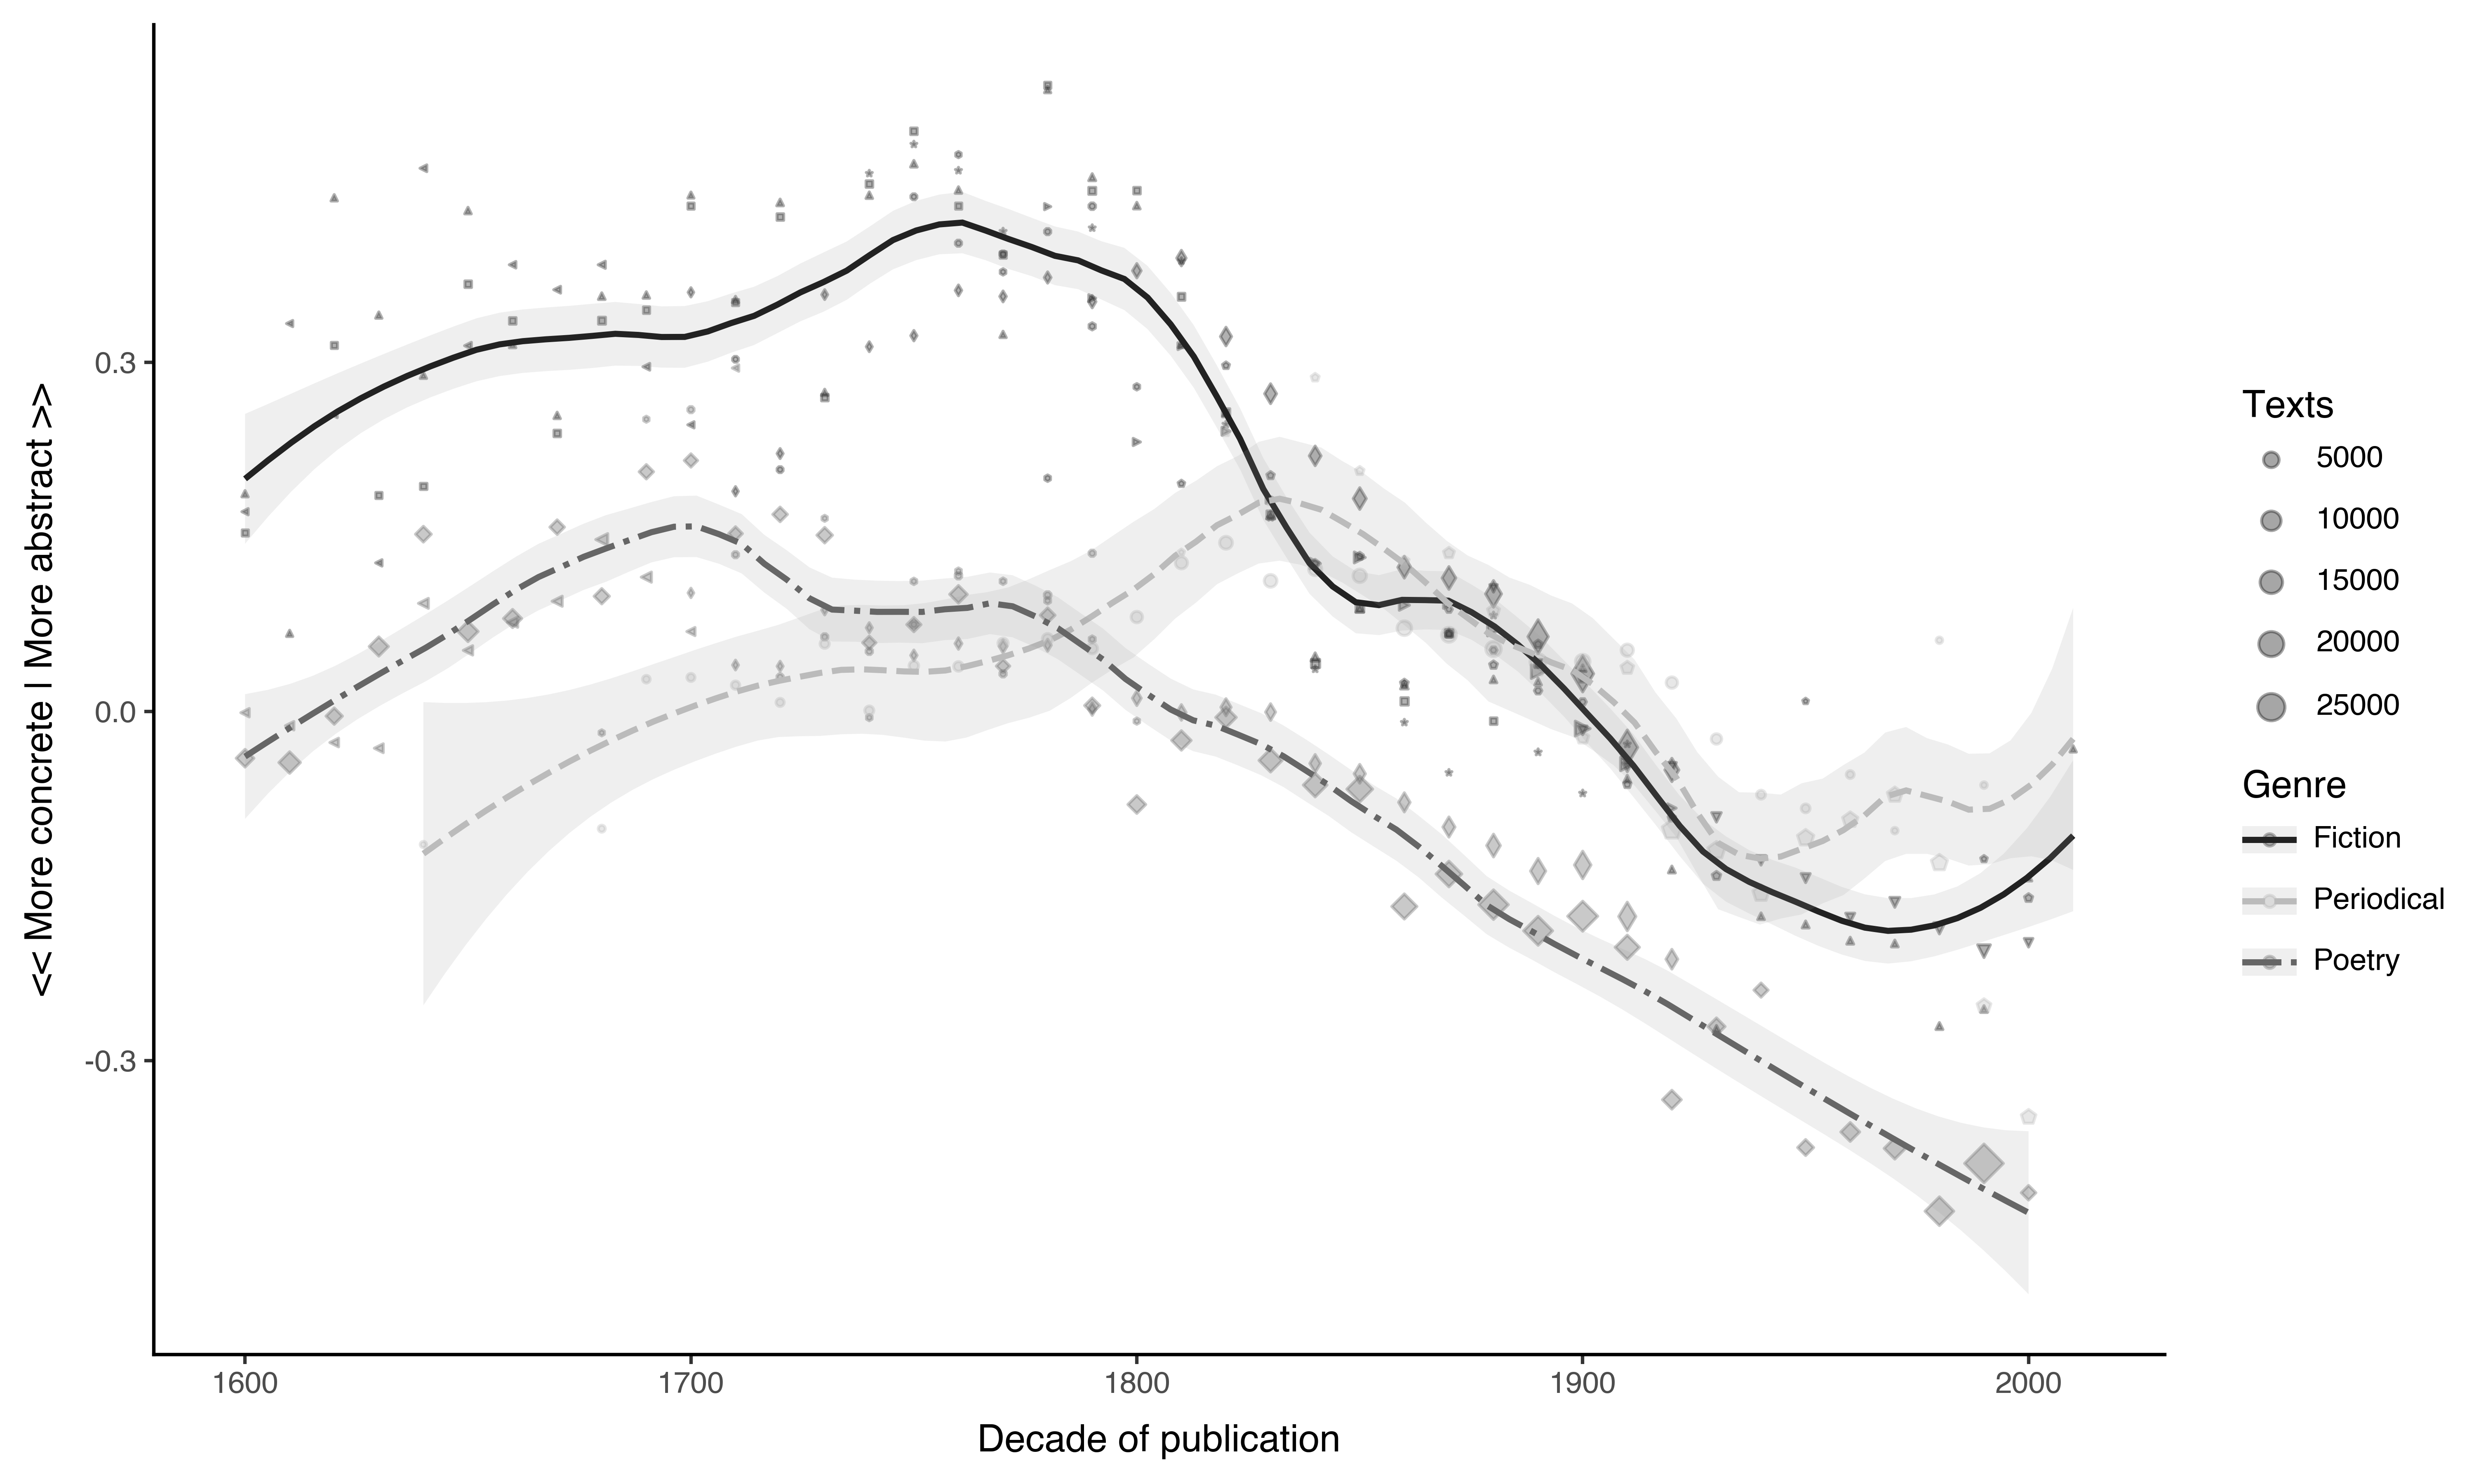

In [19]:
import plotnine as p9

fig=plot_arc_by_genre(
    combined2, 
    model='cubic', 
    show_facet=False, 
    show_fit=False, 
    show_loess=True, 
    show_lines=False, 
    min_year=1600, 
    max_year=2026, 
    invert=True
)
fig+=p9.scale_color_manual(values=colors)
fig+=p9.scale_fill_manual(values=colors)
# fig+=p9.theme_minimal()
fig+=p9.theme(
    figure_size=(10, 6),
    legend_position="right",
    # plot_background=p9.element_rect(fill="white"),
    panel_background=p9.element_rect(fill="white"),
    plot_caption = p9.element_text(size=8)
)

caption1 = '    ' + (caption.replace('\n', '\n    '))
caption2 = f'''Data:
{caption1}

Method: Historically-situated concreteness scores per word calculated using historical word embedding models, seeded by concreteness norms from Brysbaert et al 
and other sources. A text is modeled as a weighted average of its word concreteness scores, weighted by word frequency in the text.

Adjustment: Each text is scored by decade and corpus, then corpus-level intercepts are removed via OLS fixed effects so that corpora with systematically higher 
or lower scores do not shift the trend. The plotted points show these corpus-adjusted decade means; point size reflects the number of texts in each bin. 
The smooth is a LOESS fit (span = 0.3) on the adjusted points, with 95% confidence band.

Note: Date of publication in Chadwyck Poetry is estimated as author date of birth + 30 years, given inconsistent publication dates in the metadata.'''

fig+=p9.labs(
    x="Decade of publication",
    # title="Abstractness vs. concreteness in literary language across genres, 1600-2020",
    # caption=caption2,
    size='# Texts',
    linetype='Genre',
    shape='Genre',
    color='Genre',
    fill='Genre',
)
fig += p9.guides(fill=False, shape=False)


fig.save('../figures/arc-by-3genres-loess.inverted.v4.png')
fig

In [12]:
# # All genres, combined (no facet) — color by genre, shape by corpus
# fig=plot_arc_by_genre(combined2, model='quartic', show_facet=False, show_lines=False, min_year=1600, max_year=2020)
# fig+=p9.scale_color_manual(values=colors)
# fig+=p9.scale_fill_manual(values=colors)
# fig+=p9.theme(figure_size=(8, 6))
# fig+=p9.theme(legend_position="right")
# fig.save('../figures/arc-by-3genres-quartic.png')
# fig